# Quantitative-DeFi-Research

**Author:** Sana Ur Rehman  
**Profession:** Data Scientist  
**Created:** 2026  

---

## License

This project is licensed under the **MIT License**. 

You are free to use, modify, distribute, and build upon this work for both commercial and non-commercial purposes, provided you give appropriate **credit** to the original author. For the full legal text and conditions, please refer to the `LICENSE` file included in this project's repository.

---

## Citation

If you reference or build upon this project, please provide appropriate credit.

For formal citation information, please see the project's `README.md` and `CITATION.cff` files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

In [3]:
def fetch_data(ticker='ETH-USD', period='1y'):
    print(f"Fetching data for {ticker}...")
    data = yf.download(ticker, period=period, progress=False, auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    data['Return'] = np.log(data['Close'] / data['Close'].shift(1))
    data.dropna(inplace=True)
    return data

In [4]:
def run_monte_carlo(start_price, mu, sigma, days=30, simulations=10000):
    """
    Simulates price paths using Geometric Brownian Motion (GBM).
    Formula: St = S0 * exp((mu - 0.5*sigma^2)*t + sigma*Wt)
    """
    dt = 1 # 1 day time step
    
    # Generate random shocks (Brownian Motion)
    # Shape: (days, simulations)
    stochastic_component = np.random.normal(0, 1, (days, simulations))
    
    # Initialize price matrix
    price_paths = np.zeros((days + 1, simulations))
    price_paths[0] = start_price
    
    # Drift and Diffusion Calculation
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Vectorized Simulation
    for t in range(1, days + 1):
        shock = drift + diffusion * stochastic_component[t-1]
        price_paths[t] = price_paths[t-1] * np.exp(shock)
        
    return price_paths

Fetching data for ETH-USD...
--- Calibration ---
Current Price: $3272.79
Daily Drift (mu): -0.00003
Daily Vol (sigma): 0.03874

--- Risk Metrics (30-Day Horizon) ---
95% VaR Price: $2255.85 (Bottom 5% outcome)
Liquidation Probability (<$2290.95): 5.87%


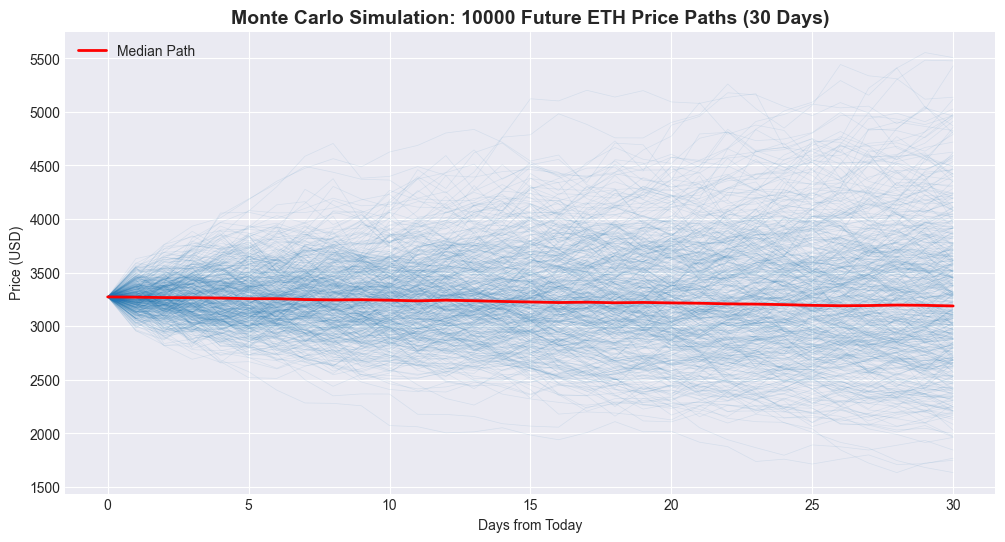

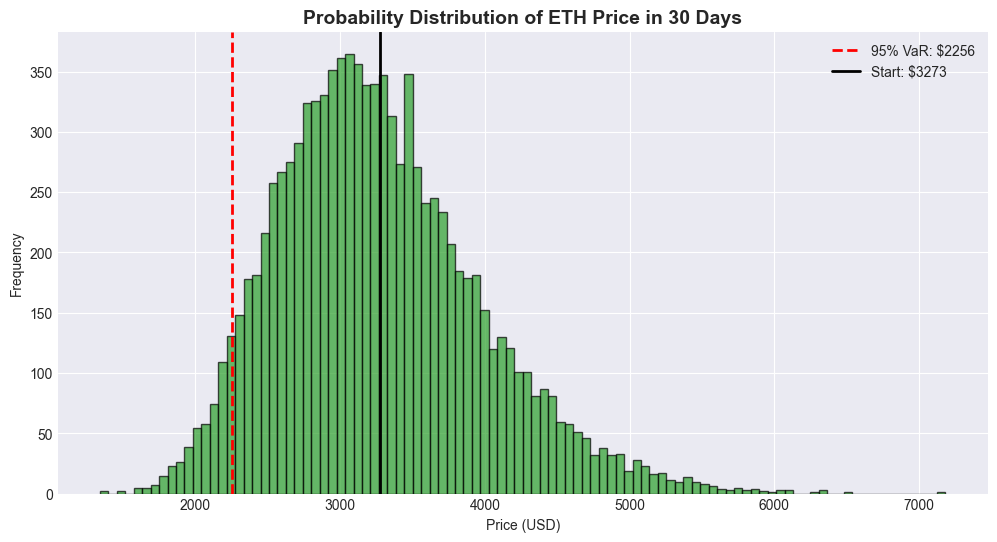

Monte Carlo charts generated.


In [5]:
if __name__ == "__main__":
    # 1. Get Data & Calibrate
    df = fetch_data()
    current_price = df['Close'].iloc[-1]
    
    # Calculate daily parameters
    mu = df['Return'].mean() # Daily Drift
    sigma = df['Return'].std() # Daily Volatility
    
    print(f"--- Calibration ---")
    print(f"Current Price: ${current_price:.2f}")
    print(f"Daily Drift (mu): {mu:.5f}")
    print(f"Daily Vol (sigma): {sigma:.5f}")
    
    # 2. Run Simulation (30 Days into future)
    DAYS = 30
    SIMS = 10000
    paths = run_monte_carlo(current_price, mu, sigma, DAYS, SIMS)
    
    # 3. Analyze Results (Risk Metrics)
    final_prices = paths[-1]
    
    # Value at Risk (VaR) at 95% Confidence
    var_95_price = np.percentile(final_prices, 5)
    
    # Liquidation Risk (Probability of dropping below specific price)
    liquidation_level = current_price * 0.70 # 30% drop
    insolvency_count = np.sum(final_prices < liquidation_level)
    insolvency_prob = insolvency_count / SIMS
    
    print(f"\n--- Risk Metrics (30-Day Horizon) ---")
    print(f"95% VaR Price: ${var_95_price:.2f} (Bottom 5% outcome)")
    print(f"Liquidation Probability (<${liquidation_level:.2f}): {insolvency_prob:.2%}")
    
    # --- PLOTTING ---
    # Plot 1: Spaghetti Plot (First 500 paths)
    plt.figure(figsize=(12, 6))
    plt.plot(paths[:, :500], alpha=0.1, color='#1f77b4', linewidth=0.5)
    plt.plot(np.median(paths, axis=1), color='red', linewidth=2, label='Median Path')
    plt.title(f'Monte Carlo Simulation: {SIMS} Future ETH Price Paths (30 Days)', fontsize=14, fontweight='bold')
    plt.xlabel('Days from Today')
    plt.ylabel('Price (USD)')
    plt.legend()
    plt.show()
    
    # Plot 2: Distribution of Final Prices
    plt.figure(figsize=(12, 6))
    plt.hist(final_prices, bins=100, color='#2ca02c', alpha=0.7, edgecolor='black')
    plt.axvline(var_95_price, color='red', linestyle='--', linewidth=2, label=f'95% VaR: ${var_95_price:.0f}')
    plt.axvline(current_price, color='black', linestyle='-', linewidth=2, label=f'Start: ${current_price:.0f}')
    plt.title('Probability Distribution of ETH Price in 30 Days', fontsize=14, fontweight='bold')
    plt.xlabel('Price (USD)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()
    
    print("Monte Carlo charts generated.")